# Lesson 6.4 — Pseudoinverse and Damped Least Squares via the SVD
**Module 6 · Unit 6 · Lesson 24**

J⁺ = V Σ⁺ Uᵀ inverts the singular values (1/σ blows up). DLS replaces 1/σ with σ/(σ²+λ²): J⁺_λ = V diag(σ/(σ²+λ²)) Uᵀ = Jᵀ(JJᵀ+λ²I)⁻¹. This **re-derives M5's damped inverse**.

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
P2=[(0,0,1,0),(0,0,1,0)]; T2=["R","R"]
P3=[(0,0,1,0),(0,0,1,0),(0,0,0.6,0)]; T3=["R","R","R"]


## Pseudoinverse via SVD matches np.linalg.pinv

In [2]:
checks=[]
J=Jv_planar(P2,T2,np.array([0.4,0.08])); U,S,Vt=np.linalg.svd(J)
Jpinv_svd = Vt.T@np.diag(1/S)@U.T
checks.append(np.allclose(Jpinv_svd, np.linalg.pinv(J), atol=1e-9))
print("J+ (SVD) == np.linalg.pinv:",checks[-1])

J+ (SVD) == np.linalg.pinv: True


## Damped least squares: two forms agree; gain σ/(σ²+λ²) is bounded

In [3]:
lam=0.1
dls_normal = J.T@np.linalg.inv(J@J.T + lam**2*np.eye(2))
gains = S/(S**2+lam**2)
dls_svd = Vt.T@np.diag(gains)@U.T
checks.append(np.allclose(dls_normal, dls_svd, atol=1e-9))
print("DLS normal form == DLS SVD form:",checks[-1])
print("gains sigma/(sigma^2+lam^2):",np.round(gains,3)," ceiling 1/(2lam) =",round(1/(2*lam),2))
checks.append(np.all(gains <= 1/(2*lam)+1e-9))

DLS normal form == DLS SVD form: True
gains sigma/(sigma^2+lam^2): [0.447 3.171]  ceiling 1/(2lam) = 5.0


## Near a singularity: pseudoinverse blows up, DLS stays bounded

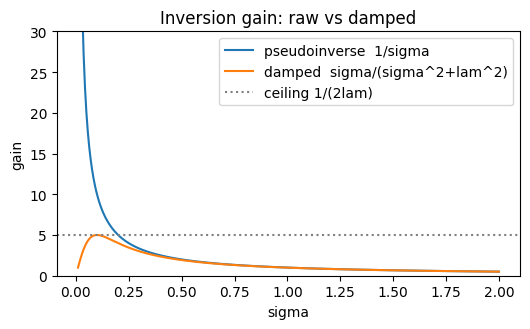

sigma_min=0.0358  ||qdot|| pinv=27.96  dls=3.171
This is exactly M5's damped inverse, now derived from the SVD.
All checks passed.


In [4]:
import matplotlib.pyplot as plt
sig=np.linspace(0.01,2,300)
plt.figure(figsize=(5.4,3.4))
plt.plot(sig,1/sig,label='pseudoinverse  1/sigma')
plt.plot(sig,sig/(sig**2+lam**2),label='damped  sigma/(sigma^2+lam^2)')
plt.axhline(1/(2*lam),ls=':',color='gray',label='ceiling 1/(2lam)')
plt.ylim(0,30); plt.xlabel('sigma'); plt.ylabel('gain'); plt.legend(); plt.title('Inversion gain: raw vs damped'); plt.tight_layout(); plt.show()
# joint-rate cost in the lost direction
xi=U[:,1]
qd_pinv=np.linalg.pinv(J)@xi; qd_dls=dls_svd@xi
print(f"sigma_min={S[-1]:.4f}  ||qdot|| pinv={np.linalg.norm(qd_pinv):.2f}  dls={np.linalg.norm(qd_dls):.3f}")
checks.append(np.linalg.norm(qd_dls) < np.linalg.norm(qd_pinv))
print("This is exactly M5's damped inverse, now derived from the SVD.")
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")